In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (15, 8)

In [17]:
df = pd.read_csv("freelancer_vs_skillstack.csv")
df.head()

,freelancer_id,category,primary_skills,years_experience,experience_level,region,country,education,hourly_rate_usd,annual_income_usd,primary_platform
0,FL0001,AI/ML Engineering,"Computer Vision, TensorFlow, Data Science",1.6,junior,Middle East,Israel,Master,66.41,"$58,873.61",Direct Client
1,FL0002,Backend Development,"PHP, Ruby, Go",8.3,senior,Middle East,UAE,Bootcamp,112.79,"$108,183.05",Freelancer
2,FL0003,UI/UX Design,"Sketch, Wireframing, Adobe XD",3.6,mid,North America,US,Self-taught,94.21,"$88,681.22",Freelancer
3,FL0004,DevOps,"Kubernetes, Terraform, AWS",2.3,mid,North America,US,Self-taught,118.87,"$109,229.42",Upwork
4,FL0005,DevOps,"Azure, Docker, Kubernetes",8.8,senior,Latin America,Mexico,Self-taught,82.76,"$66,298.22",LinkedIn


In [18]:
df.head()
df.tail()
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   freelancer_id      500 non-null    object 
 1   category           500 non-null    object 
 2   primary_skills     500 non-null    object 
 3   years_experience   500 non-null    float64
 4   experience_level   500 non-null    object 
 5   region             500 non-null    object 
 6   country            500 non-null    object 
 7   education          500 non-null    object 
 8   hourly_rate_usd    500 non-null    float64
 9   annual_income_usd  500 non-null    object 
 10  primary_platform   500 non-null    object 
dtypes: float64(2), object(9)
memory usage: 43.1+ KB


,years_experience,hourly_rate_usd
count,500.000000,500.000000
mean,5.850000,97.149820
std,2.934779,52.697831
min,0.500000,17.280000
25%,3.600000,55.182500
50%,5.600000,84.445000
75%,7.800000,130.497500
max,14.000000,281.470000


In [19]:
df.dtypes

,0
freelancer_id,object
category,object
primary_skills,object
years_experience,float64
experience_level,object
region,object
country,object
education,object
hourly_rate_usd,float64
annual_income_usd,object


In [20]:
# check percentage of missing data
missing_df = df.isnull().sum().reset_index()
missing_df.columns = ['Column', 'Missing_Values']
missing_df['Missing_percent'] = (missing_df['Missing_Values'] / len(df)) * 100
missing_df.sort_values(by='Missing_percent', ascending=False)

,Column,Missing_Values,Missing_percent
0,freelancer_id,0,0.0
1,category,0,0.0
2,primary_skills,0,0.0
3,years_experience,0,0.0
4,experience_level,0,0.0
5,region,0,0.0
6,country,0,0.0
7,education,0,0.0
8,hourly_rate_usd,0,0.0
9,annual_income_usd,0,0.0


In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
years_experience,500.0,5.85000,2.934779,0.50,3.6000,5.600,7.8000,14.00
hourly_rate_usd,500.0,97.14982,52.697831,17.28,55.1825,84.445,130.4975,281.47


In [23]:
df.describe(include='object').T

,count,unique,top,freq
freelancer_id,500,500,FL0500,1
category,500,10,Cybersecurity,68
primary_skills,500,377,"Network Security, Penetration Testing, Cryptog...",6
experience_level,500,3,senior,279
region,500,7,Eastern Europe,84
country,500,22,Israel,42
education,500,5,Bachelor,187
annual_income_usd,500,500,"$136,126.59",1
primary_platform,500,7,Direct Client,143


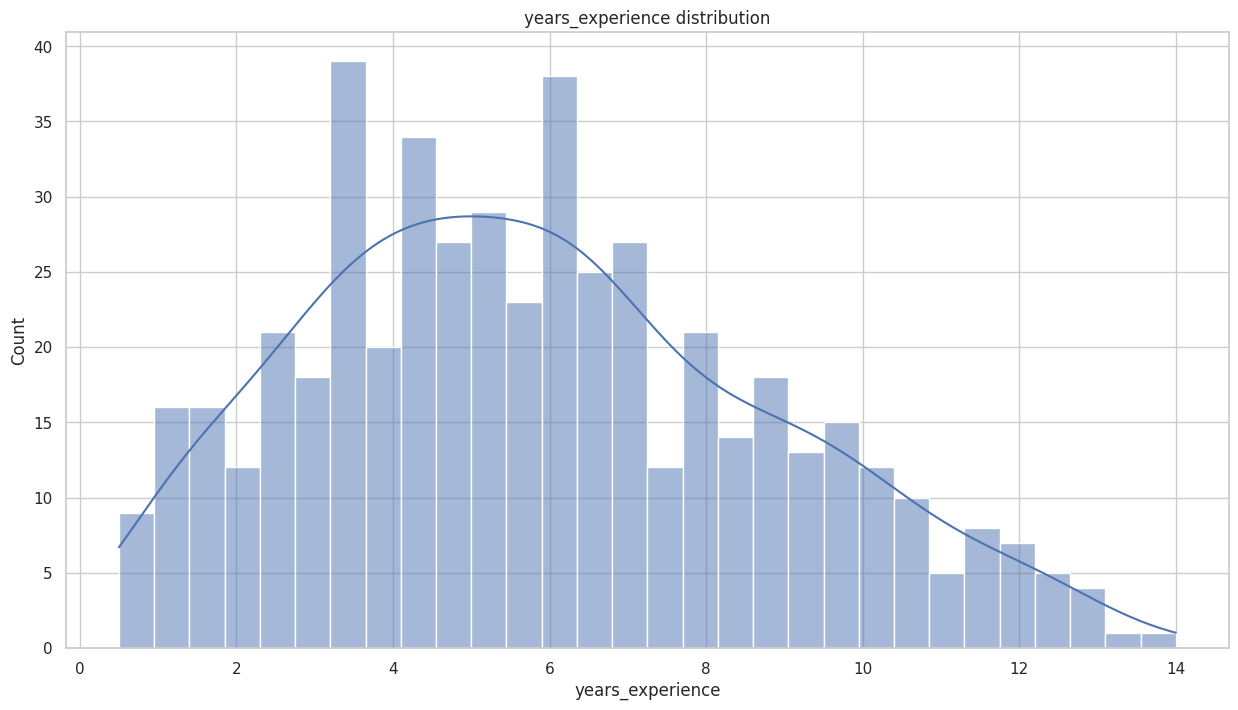

In [24]:
from scipy.__config__ import show
sns.histplot(df['years_experience'], bins=30, kde=True)
plt.title('years_experience distribution')
plt.show()

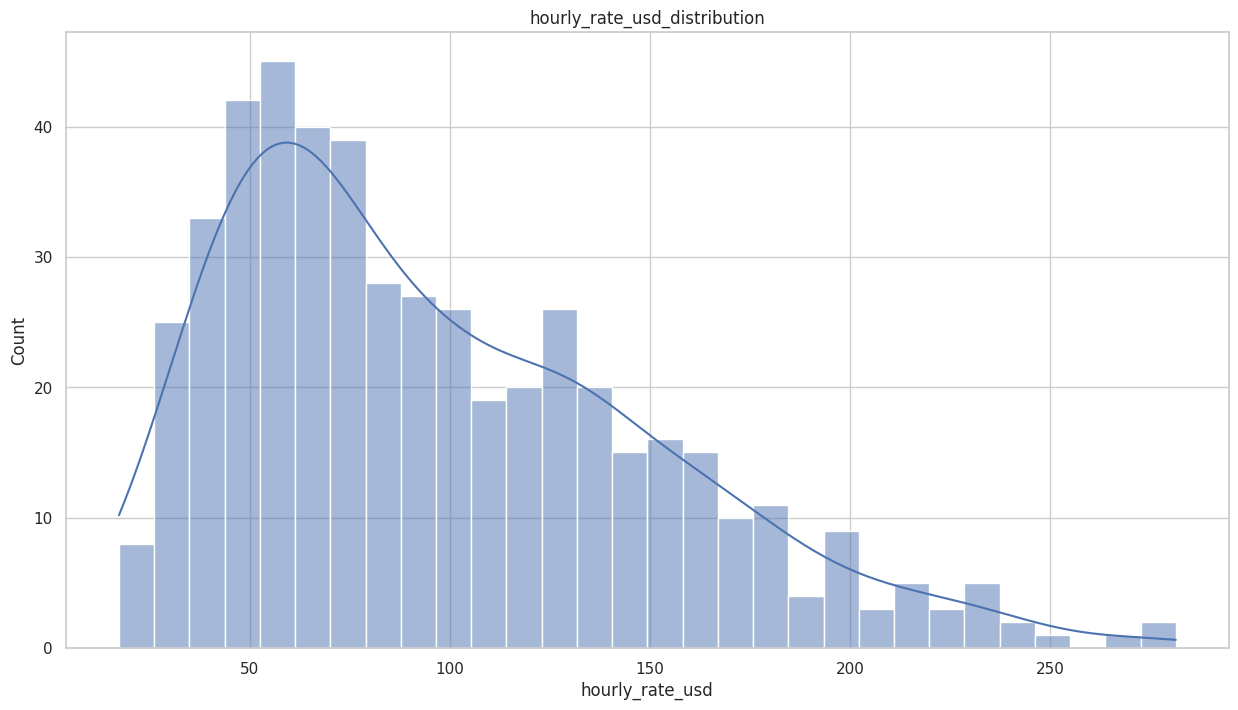

In [25]:
sns.histplot(df['hourly_rate_usd'], bins=30, kde=True)
plt.title('hourly_rate_usd_distribution')
plt.show()

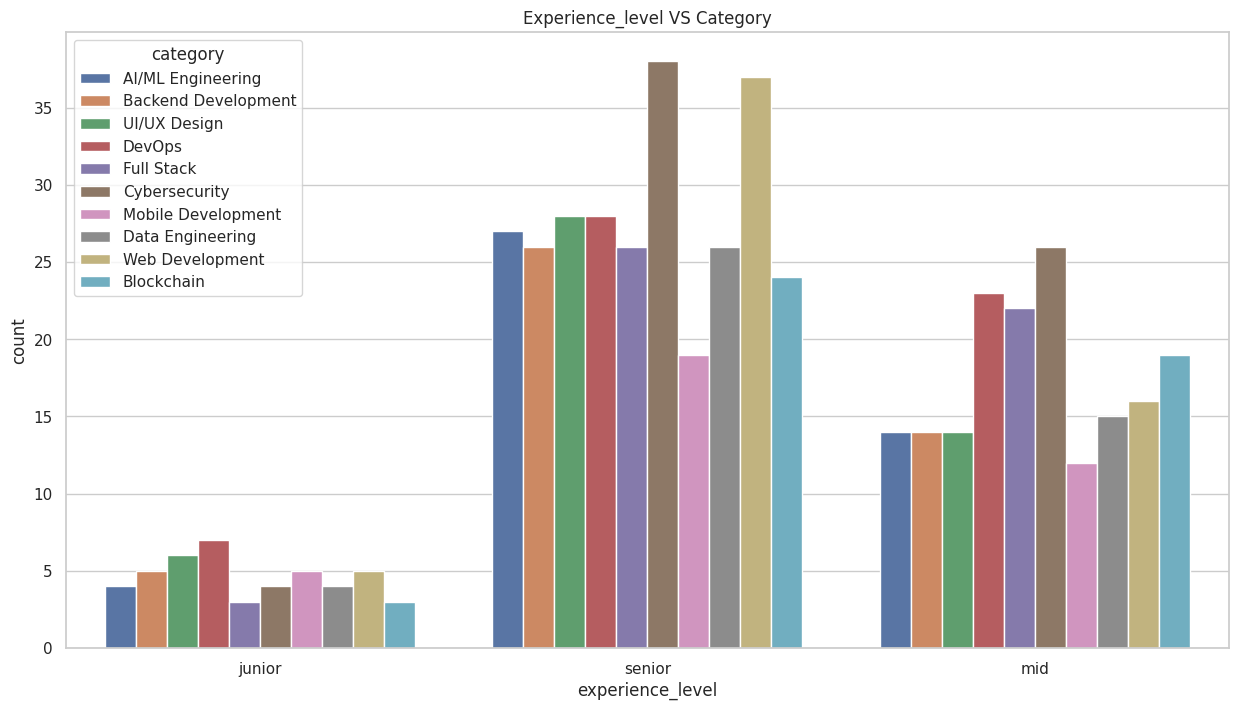

In [26]:
# Categorical Analysis
# experience_level vs category
sns.countplot(x='experience_level', hue='category', data=df)
plt.title('Experience_level VS Category')
plt.show()

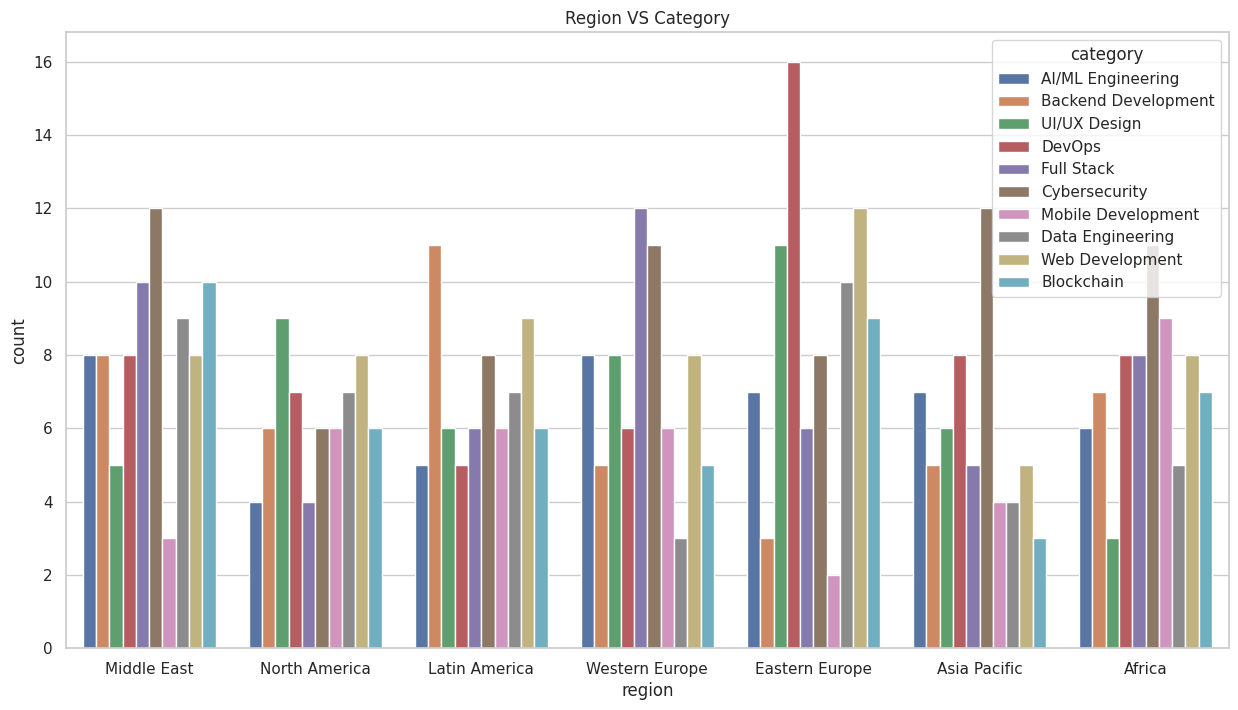

In [27]:
# region vs category
sns.countplot(x='region', hue='category', data=df)
plt.title('Region VS Category')
plt.show()

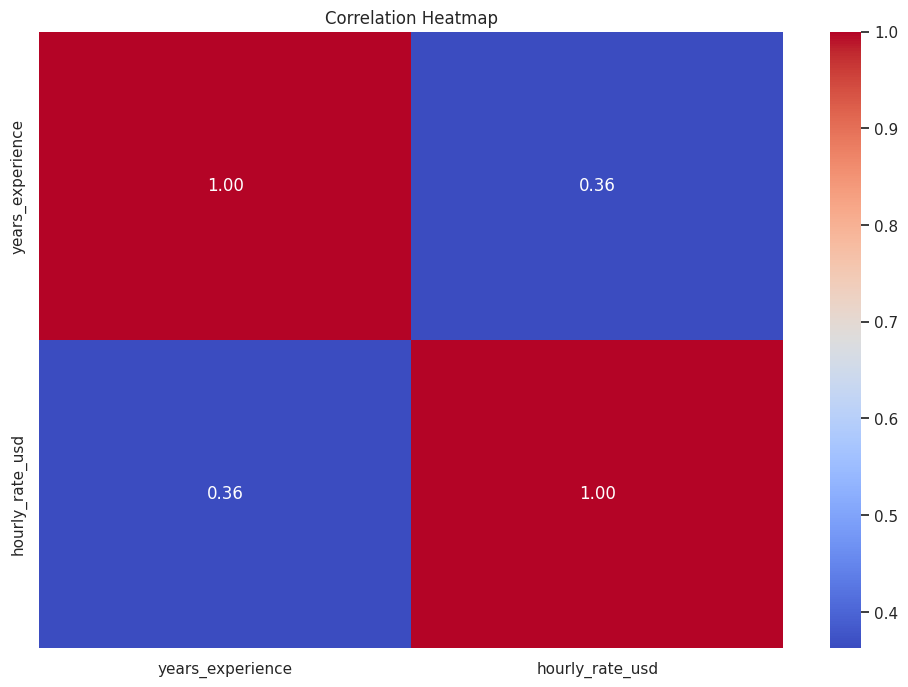

In [28]:
# Corlation Analysis
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()